# SyriaTel Customer Churn Prediction - Phase 3 project

**Author:** Angela Mukami K

**Date:** February 2026

---

## Table of Contents

1. [Business Understanding](#business-understanding)
2. [Data Understanding](#data-understanding)
3. [Data Preparation](#data-preparation)
4. [Modeling](#modeling)
5. [Evaluation](#evaluation)
6. [Conclusions and Recommendations](#conclusions-and-recommendations)

---

## 1. Business Understanding <a id='business-understanding'></a>

### Stakeholder
SyriaTel, a telecommunications company

### Business Problem
SyriaTel is experiencing customer churn, which directly impacts revenue and profitability. When customers leave, the company loses not only their recurring revenue but also the investment made in acquiring them. 

### Project Objective
Build a classification model to predict whether a customer will churn (stop doing business with SyriaTel) based on their account information and usage patterns.

### Success Criteria
- Identify key features that predict customer churn
- Build a model with strong predictive performance
- Provide actionable recommendations to reduce churn

### Why Classification?
This is a binary classification problem because our target variable (churn) is categorical:
- Class 0: Customer stays
- Class 1: Customer churns

We need to predict which category a customer falls into, not a numeric value.

---

## 2. Data Understanding <a id='data-understanding'></a>

### 2.1 Import Libraries

In [9]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix, 
    classification_report,
    roc_auc_score,
    roc_curve
)

# Model tuning
from sklearn.model_selection import GridSearchCV, cross_val_score

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


### 2.2 Load Data

In [10]:
# Load the dataset
# Update the filename below to match your dataset file name
df = pd.read_csv('syriatel_data.csv')

# Display first few rows
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### 2.3 Initial Data Exploration

In [11]:
# Dataset shape
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (3333, 21)
Number of rows: 3333
Number of columns: 21


In [12]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [10]:
# Statistical summary
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [11]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

Total missing values: 0


In [12]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


### 2.4 Target Variable Analysis

In [13]:
# we will take 'churn' as the target variable
target_col = 'churn'  

# Check target variable distribution
print("Target variable distribution:")
print(df[target_col].value_counts())
print("\nPercentages:")
print(df[target_col].value_counts(normalize=True) * 100)

Target variable distribution:
churn
False    2850
True      483
Name: count, dtype: int64

Percentages:
churn
False    85.508551
True     14.491449
Name: proportion, dtype: float64


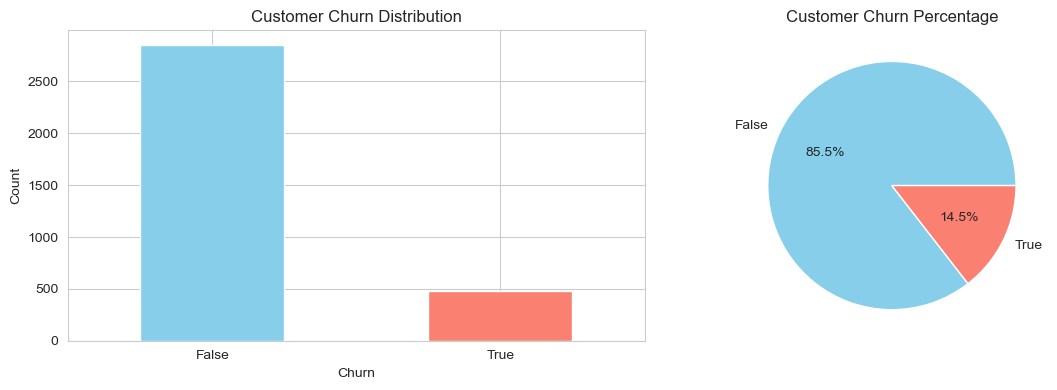

In [14]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Customer Churn Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie chart
df[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['skyblue', 'salmon'])
axes[1].set_title('Customer Churn Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Observations:**
- [Note if the dataset is balanced or imbalanced]
- [Any initial insights about the target variable]

### 2.6 Key Insights from EDA

**Summary of findings:**
- [List key patterns observed]
- [Note any data quality issues]
- [Identify potential important features]
- [Class imbalance observations]
- [Any outliers or unusual patterns]

---

## 3. Data Preparation <a id='data-preparation'></a>

### 3.1 Handle Missing Values

In [14]:
# Check again for missing values
print("Missing values:")
print(df.isnull().sum())

# If there are missing values, decide on a strategy:
# - Drop rows with missing values
# - Fill with mean/median/mode

# Example: Drop rows with missing values (if any)
# df = df.dropna()

# Example: Fill numeric columns with median
# for col in numeric_cols:
#     if df[col].isnull().sum() > 0:
#         df[col].fillna(df[col].median(), inplace=True)

print(f"\nDataset shape after handling missing values: {df.shape}")

Missing values:
state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

Dataset shape after handling missing values: (3333, 21)


### 3.3 Feature Engineering

Now we will create new features (feature engineering)

First feature =  Total Minutes/Calls/Charge - Overall usage aggregates

Business Logic:

Currently we have minutes split by time of day (day, evening, night, international)
But what if overall usage matters more than when they call?
Heavy users (high total minutes) might be more valuable and less likely to churn
Or maybe low users are at risk because they don't see value in the service

Why this helps the model:

Reduces complexity - instead of 4 separate features, we have 1 aggregate
Captures overall engagement level

In [15]:
# 1. Total Minutes/Calls/Charge - Overall usage aggregates
df['total_minutes'] = (df['total day minutes'] + df['total eve minutes'] + 
                       df['total night minutes'] + df['total intl minutes'])

df['total_calls'] = (df['total day calls'] + df['total eve calls'] + 
                     df['total night calls'] + df['total intl calls'])

df['total_charge'] = (df['total day charge'] + df['total eve charge'] + 
                      df['total night charge'] + df['total intl charge'])

Second feature = average call duration

Business Logic:

Are customers making many short calls or few long calls?
Long calls might indicate personal/emotional connections (less likely to churn)
Very short calls might indicate quick business use or frustration

Example:

Customer A: 100 minutes in 10 calls = 10 min/call (long conversations)
Customer B: 100 minutes in 100 calls = 1 min/call (quick calls)


Why this helps the model:

Reveals usage behavior pattern not visible from just minutes or calls alone
Two customers can have same total minutes but very different behavior

In [16]:
# 2. Average Call Duration - Usage behavior pattern
df['average_call_duration'] = df['total_minutes'] / df['total_calls'].replace(0, 1)

third feature = daily minute ratio

Business Logic:

High ratio (mostly daytime calls) = probably business use
Low ratio (mostly evening/night) = probably personal use
Business users might churn if they change jobs or company switches providers
Personal users might be more loyal

Why this helps the model:

Identifies customer usage profile
More interpretable than raw minutes

In [17]:
# 3. Day Minute Ratio - Identifies business vs personal users
df['day_minute_ratio'] = df['total day minutes'] / df['total_minutes'].replace(0, 1)

In [18]:
print("Feature engineering complete!")
print(f"Dataset shape before: (3333, 21)")
print(f"Dataset shape after: {df.shape}")
print(f"New features created: {df.shape[1] - 21}")

# Verify the new features
print("\n" + "="*60)
print("VERIFYING NEW FEATURES")
print("="*60)

# Show dataset info with new columns
print("\nDataset Info:")
df.info()

# Display first few rows to see new columns
print("\nFirst 5 rows (showing new features):")
df.head()

Feature engineering complete!
Dataset shape before: (3333, 21)
Dataset shape after: (3333, 26)
New features created: 5

VERIFYING NEW FEATURES

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   i

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,total_minutes,total_calls,total_charge,average_call_duration,day_minute_ratio
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,717.2,303,75.56,2.366997,0.369632
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,625.2,332,59.24,1.883133,0.258477
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,539.4,333,62.29,1.619820,0.451242
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False,564.8,255,66.80,2.214902,0.530099
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False,512.0,359,52.09,1.426184,0.325586


### 3.4 Prepare Features and Target

In [19]:
# Drop redundant columns now that we have aggregated features
columns_to_drop = [
    'churn',  # Target variable
    # Time-specific features (we created aggregates)
    'total day minutes', 'total day calls', 'total day charge',
    'total eve minutes', 'total eve calls', 'total eve charge', 
    'total night minutes', 'total night calls', 'total night charge',
    'total intl minutes', 'total intl calls', 'total intl charge',
    # Not useful for prediction
    'phone number'
]

# Separate features and target
X = df.drop(columns=columns_to_drop)
y = df['churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Identify column types (useful for preprocessing)
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

print("\n" + "="*60)
print("FEATURES INCLUDED IN MODEL:")
print("="*60)
print(X.columns.tolist())

Features shape: (3333, 12)
Target shape: (3333,)

Numeric columns (9): ['account length', 'area code', 'number vmail messages', 'customer service calls', 'total_minutes', 'total_calls', 'total_charge', 'average_call_duration', 'day_minute_ratio']

Categorical columns (3): ['state', 'international plan', 'voice mail plan']

FEATURES INCLUDED IN MODEL:
['state', 'account length', 'area code', 'international plan', 'voice mail plan', 'number vmail messages', 'customer service calls', 'total_minutes', 'total_calls', 'total_charge', 'average_call_duration', 'day_minute_ratio']


### 3.5 Handle Categorical Variables

In [20]:
# One-Hot Encode all categorical variables
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"X shape after encoding: {X.shape}")
print("✓ Categorical encoding complete!")

X shape after encoding: (3333, 61)
✓ Categorical encoding complete!


### 3.6 Train-Test Split

**Important:** We perform the train-test split BEFORE any transformations (scaling, etc.) to prevent data leakage.

In [21]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80-20 split
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:\n{y_train.value_counts()}")
print(f"\nTest set target distribution:\n{y_test.value_counts()}")

Training set size: 2666 samples
Test set size: 667 samples

Training set target distribution:
churn
False    2280
True      386
Name: count, dtype: int64

Test set target distribution:
churn
False    570
True      97
Name: count, dtype: int64


### 3.7 Feature Scaling

**Why Feature Scaling is Necessary:**

Our features have vastly different ranges:
- `account_length`: 1 to 243
- `total_minutes`: 0 to 500+
- `customer_service_calls`: 0 to 9
- `state_OH` (encoded): 0 or 1

This creates a problem for distance-based models like Logistic Regression. Features with larger ranges (like `total_minutes` with values up to 500) will dominate the model's decisions compared to features with smaller ranges (like `state_OH` with values 0 or 1). The model might incorrectly assume that larger-valued features are more important.

**What is StandardScaler?**

StandardScaler transforms each feature to have:
- Mean = 0
- Standard deviation = 1

This puts all features on the same scale, ensuring each feature contributes equally to the model.

**Preventing Data Leakage:**

This is the most critical aspect of feature scaling. We must:
1. **Fit the scaler ONLY on training data** - the scaler learns the mean and standard deviation from training data
2. **Transform both training and test data** - we apply the same transformation to both sets

**Why this prevents leakage:**
If we fit the scaler on test data, the model would "learn" information from the test set during preprocessing, which would artificially inflate our performance metrics. The test set must remain completely unseen until evaluation.

**Which Models Need Scaling?**

- ✅ **Logistic Regression** (our baseline) - uses distances, NEEDS scaling
- ✅ **K-Nearest Neighbors** - calculates distances between points, NEEDS scaling
- ❌ **Decision Trees** - uses thresholds, does NOT need scaling
- ❌ **Random Forest** - tree-based, does NOT need scaling

We will use the scaled data (`X_train_scaled`, `X_test_scaled`) for distance-based models and the unscaled data (`X_train`, `X_test`) for tree-based models.

In [22]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier manipulation (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling complete!")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

Feature scaling complete!
Scaled training data shape: (2666, 61)
Scaled test data shape: (667, 61)


---

## 4. Modeling <a id='modeling'></a>

We will follow an iterative approach:
1. Start with a simple baseline model
2. Evaluate performance
3. Try different models
4. Tune hyperparameters
5. Compare and select the best model

### 4.1 Baseline Model: Logistic Regression

We'll start with a simple logistic regression model as our baseline. Logistic regression is:
- Easy to interpret
- Works well for binary classification
- A good starting point to compare other models against

**Important:** We use the SCALED data (X_train_scaled, X_test_scaled) because logistic regression is a distance-based model.

In [23]:
from sklearn.linear_model import LogisticRegression

# Instantiate the model
baseline_model = LogisticRegression(random_state=42, max_iter=1000)

print("Model instantiated:")
print(baseline_model)

Model instantiated:
LogisticRegression(max_iter=1000, random_state=42)


In [26]:
# Fit the model on training data
baseline_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [27]:
# Fit the model on training data
baseline_model.fit(X_train_scaled, y_train)

print("✓ Model training complete!")

✓ Model training complete!


In [29]:
# Make predictions on both training and test data
y_train_pred = baseline_model.predict(X_train_scaled)
y_test_pred = baseline_model.predict(X_test_scaled)

print("✓ Predictions complete!")


✓ Predictions complete!


In [30]:
# Calculate accuracy on BOTH train and test to check for overfitting
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Calculate other metrics ONLY on test data (what matters for real-world performance)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# Print results
print("="*60)
print("Baseline Logistic Regression Performance")
print("="*60)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1-Score:          {f1:.4f}")
print("="*60)

# Check for overfitting
if train_accuracy - test_accuracy > 0.05:
    print("\n⚠️  Warning: Model may be overfitting (train accuracy much higher than test)")
else:
    print("\n✓ Good! No significant overfitting detected")

Baseline Logistic Regression Performance
Training Accuracy: 0.8706
Test Accuracy:     0.8501
Precision:         0.4706
Recall:            0.2474
F1-Score:          0.3243

✓ Good! No significant overfitting detected


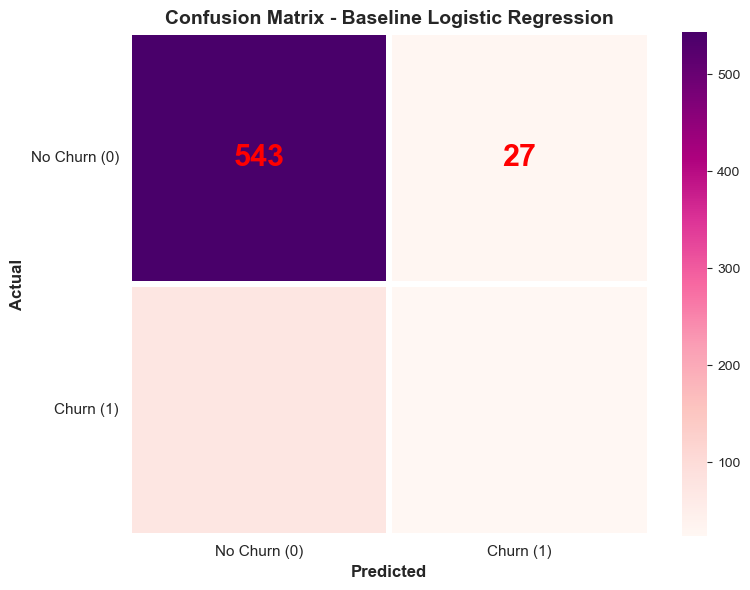

In [42]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot with darker colors
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', cbar=True, 
            annot_kws={"size": 22, "weight": "bold", "color": "red"},
            linewidths=3, linecolor='white')

# Add labels
plt.title('Confusion Matrix - Baseline Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')

# Change tick labels
plt.xticks([0.5, 1.5], ['No Churn (0)', 'Churn (1)'], rotation=0, fontsize=11)
plt.yticks([0.5, 1.5], ['No Churn (0)', 'Churn (1)'], rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

In [44]:
# Print the confusion matrix values to see what we're dealing with
print("Confusion Matrix Values:")
print(cm)
print()
print(f"True Negatives (Correct No Churn):  {cm[0,0]}")
print(f"False Positives (Predicted Churn, Actually Stayed): {cm[0,1]}")
print(f"False Negatives (Predicted Stay, Actually Churned): {cm[1,0]}")
print(f"True Positives (Correct Churn):     {cm[1,1]}")

Confusion Matrix Values:
[[543  27]
 [ 73  24]]

True Negatives (Correct No Churn):  543
False Positives (Predicted Churn, Actually Stayed): 27
False Negatives (Predicted Stay, Actually Churned): 73
True Positives (Correct Churn):     24


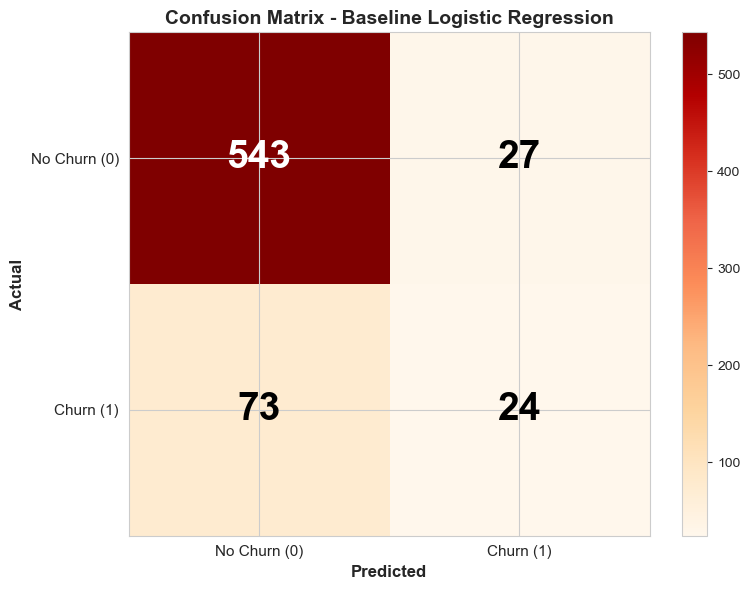

In [45]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot with manual text color control
im = ax.imshow(cm, cmap='OrRd', aspect='auto')

# Manually add text to each cell with contrasting colors
for i in range(2):
    for j in range(2):
        # Use white text on dark backgrounds, black on light
        text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center", 
                      color=text_color, fontsize=28, fontweight='bold')

# Set labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'], fontsize=11)
ax.set_yticklabels(['No Churn (0)', 'Churn (1)'], fontsize=11)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Baseline Logistic Regression', fontsize=14, fontweight='bold')

# Add colorbar
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

**Baseline Model Observations:**

The confusion matrix reveals a critical issue with our baseline model:

- **Strong at identifying non-churners**: 543 correct predictions out of 570 (95%)
- **Weak at catching churners**: Only 24 out of 97 actual churners detected (25% recall)
- **Problem**: The model misses 73 customers who will churn

**Business Context:**
For SyriaTel, missing churners is very costly. Each of those 73 missed customers represents lost revenue. While we don't want to waste retention efforts on customers who aren't at risk (false positives), missing 75% of actual churners is unacceptable.

**Next Steps:**
We need to improve recall (catching more churners) in our next models. This might mean accepting more false positives, but that's a better trade-off than losing customers.

In [46]:
# Print detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.95      0.92       570
        True       0.47      0.25      0.32        97

    accuracy                           0.85       667
   macro avg       0.68      0.60      0.62       667
weighted avg       0.82      0.85      0.83       667



In [47]:
# Store results for later comparison
baseline_results = {
    'Model': 'Baseline Logistic Regression',
    'Train_Accuracy': train_accuracy,
    'Test_Accuracy': test_accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1_Score': f1
}

print("✓ Results stored for comparison!")

✓ Results stored for comparison!


**Baseline Model Observations:**
- [Note the performance metrics]
- [Identify areas for improvement]
- [Discuss which metric is most important for this business problem]

### 4.3 Model 2: Decision Tree


Decision Tree Performance
Training Accuracy: 1.0000
Test Accuracy:     0.9010
Precision:         0.6598
Recall:            0.6598
F1-Score:          0.6598

⚠️  Warning: Possible overfitting detected!




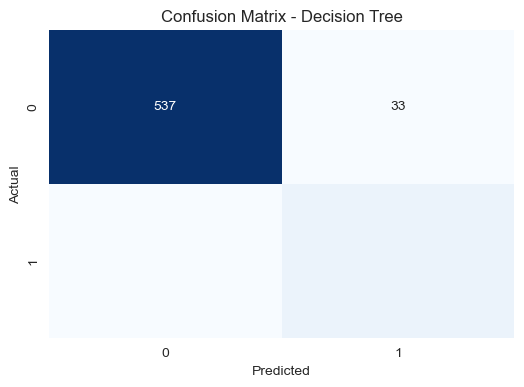

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94       570
        True       0.66      0.66      0.66        97

    accuracy                           0.90       667
   macro avg       0.80      0.80      0.80       667
weighted avg       0.90      0.90      0.90       667



In [28]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Evaluate
dt_results = evaluate_model(
    dt_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    model_name="Decision Tree"
)

**Decision Tree Observations:**
- [Compare with baseline]
- [Note any overfitting issues]
- [Discuss interpretability]

### 4.4 Model 3: Random Forest


Random Forest Performance
Training Accuracy: 1.0000
Test Accuracy:     0.9385
Precision:         0.9828
Recall:            0.5876
F1-Score:          0.7355

⚠️  Warning: Possible overfitting detected!




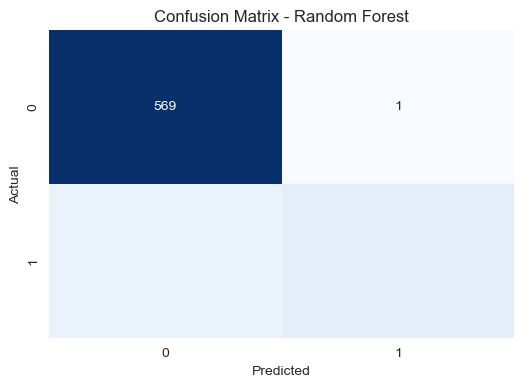

Classification Report:
              precision    recall  f1-score   support

       False       0.93      1.00      0.97       570
        True       0.98      0.59      0.74        97

    accuracy                           0.94       667
   macro avg       0.96      0.79      0.85       667
weighted avg       0.94      0.94      0.93       667



In [29]:
# Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Evaluate
rf_results = evaluate_model(
    rf_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    model_name="Random Forest"
)

### 4.5 Hyperparameter Tuning

Let's tune the hyperparameters of our best performing model so far.

In [30]:
# Example: Tune Random Forest hyperparameters
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',  # Choose appropriate metric
    n_jobs=-1,
    verbose=1
)

# Fit grid search
print("Starting hyperparameter tuning...")
rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}")

Starting hyperparameter tuning...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.7924



Tuned Random Forest Performance
Training Accuracy: 1.0000
Test Accuracy:     0.9385
Precision:         0.9828
Recall:            0.5876
F1-Score:          0.7355

⚠️  Warning: Possible overfitting detected!




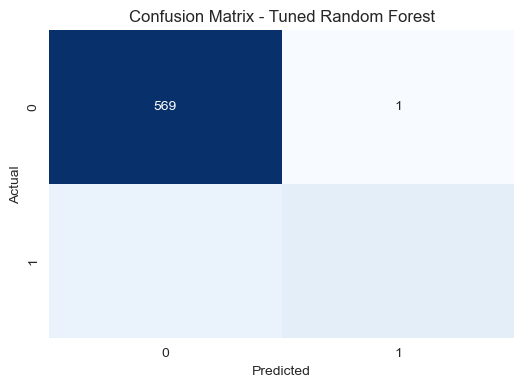

Classification Report:
              precision    recall  f1-score   support

       False       0.93      1.00      0.97       570
        True       0.98      0.59      0.74        97

    accuracy                           0.94       667
   macro avg       0.96      0.79      0.85       667
weighted avg       0.94      0.94      0.93       667



In [31]:
# Evaluate tuned model
tuned_rf_results = evaluate_model(
    rf_grid.best_estimator_,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    model_name="Tuned Random Forest"
)

**Hyperparameter Tuning Observations:**
- [Discuss improvements from tuning]
- [Explain the rationale for parameter choices]
- [Compare with untuned model]

### 4.6 Additional Models (Optional)

In [32]:
# Try other models if time permits
# Example: Gradient Boosting
# gb_model = GradientBoostingClassifier(random_state=42)
# gb_model.fit(X_train_scaled, y_train)
# gb_results = evaluate_model(gb_model, X_train_scaled, X_test_scaled, y_train, y_test, "Gradient Boosting")

### 4.7 Model Comparison

In [33]:
# Create comparison dataframe
results_df = pd.DataFrame({
    'Model': ['Baseline Logistic Regression', 'Decision Tree', 'Random Forest', 'Tuned Random Forest'],
    'Test Accuracy': [
        baseline_results['test_accuracy'],
        dt_results['test_accuracy'],
        rf_results['test_accuracy'],
        tuned_rf_results['test_accuracy']
    ],
    'Precision': [
        baseline_results['precision'],
        dt_results['precision'],
        rf_results['precision'],
        tuned_rf_results['precision']
    ],
    'Recall': [
        baseline_results['recall'],
        dt_results['recall'],
        rf_results['recall'],
        tuned_rf_results['recall']
    ],
    'F1-Score': [
        baseline_results['f1_score'],
        dt_results['f1_score'],
        rf_results['f1_score'],
        tuned_rf_results['f1_score']
    ]
})

print("\nModel Comparison:")
print(results_df.to_string(index=False))


Model Comparison:
                       Model  Test Accuracy  Precision   Recall  F1-Score
Baseline Logistic Regression       0.850075   0.470588 0.247423  0.324324
               Decision Tree       0.901049   0.659794 0.659794  0.659794
               Random Forest       0.938531   0.982759 0.587629  0.735484
         Tuned Random Forest       0.938531   0.982759 0.587629  0.735484


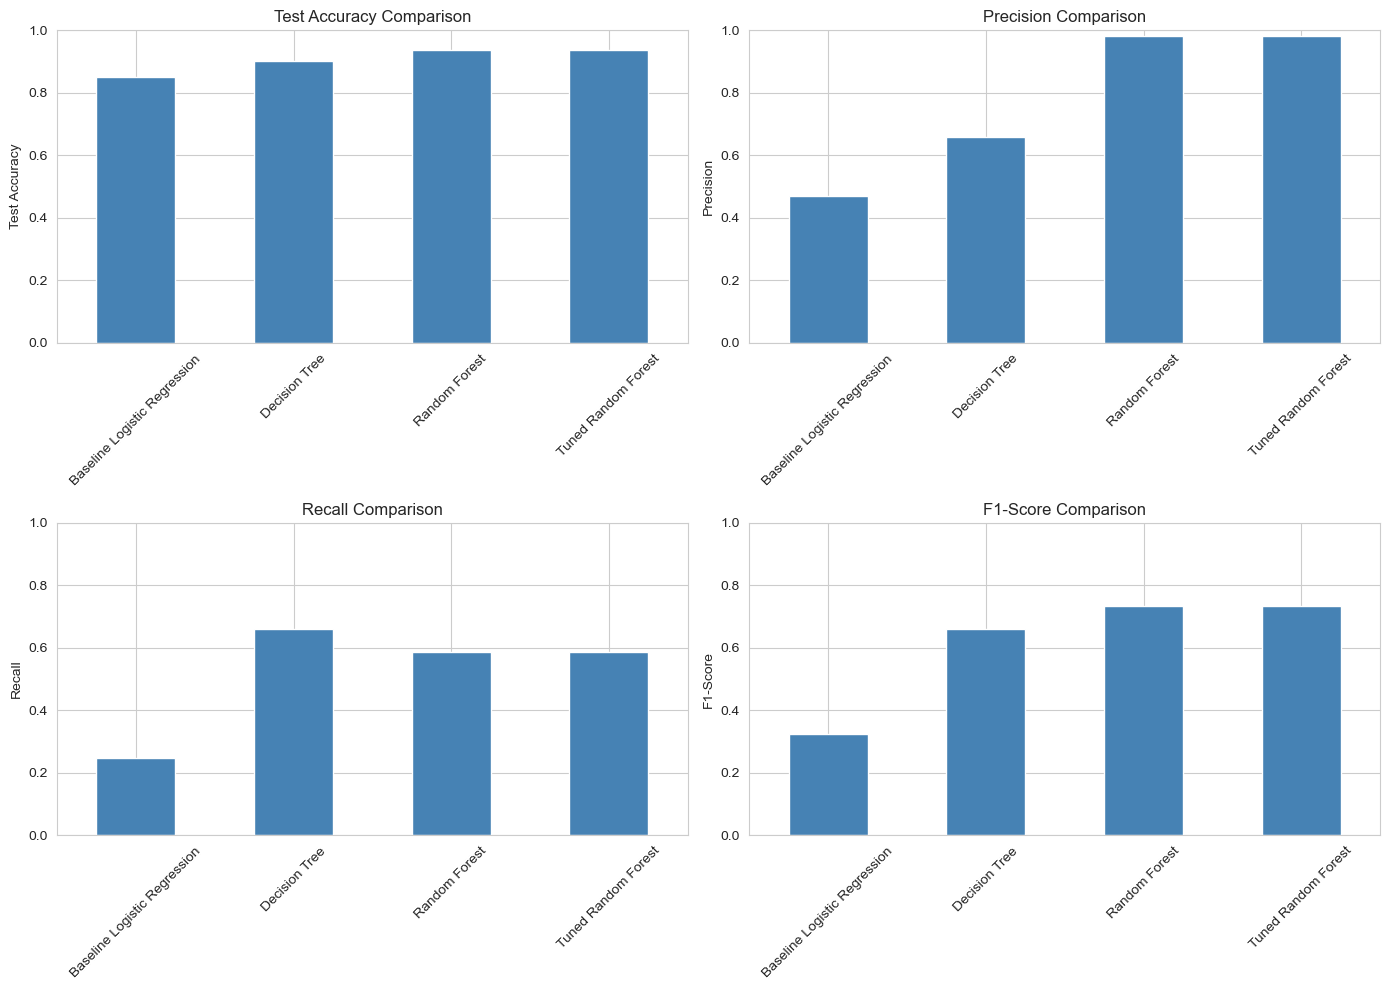

In [34]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
axes = axes.ravel()

for idx, metric in enumerate(metrics):
    results_df.plot(x='Model', y=metric, kind='bar', ax=axes[idx], legend=False, color='steelblue')
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].set_ylabel(metric)
    axes[idx].set_xlabel('')
    axes[idx].set_ylim([0, 1])
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---

## 5. Evaluation <a id='evaluation'></a>

### 5.1 Select Final Model

In [35]:
# Select your final model (update based on your results)
final_model = rf_grid.best_estimator_  # or whichever model performed best
final_model_name = "Tuned Random Forest"

print(f"Selected final model: {final_model_name}")

Selected final model: Tuned Random Forest


### 5.2 Feature Importance Analysis

Top 10 Most Important Features:
                   feature  importance
6             total_charge    0.251327
3   customer service calls    0.137747
4            total_minutes    0.121432
8         day_minute_ratio    0.072740
7    average_call_duration    0.066834
59  international plan_yes    0.053034
5              total_calls    0.051110
0           account length    0.047701
2    number vmail messages    0.042849
60     voice mail plan_yes    0.030070


<Figure size 1000x600 with 0 Axes>

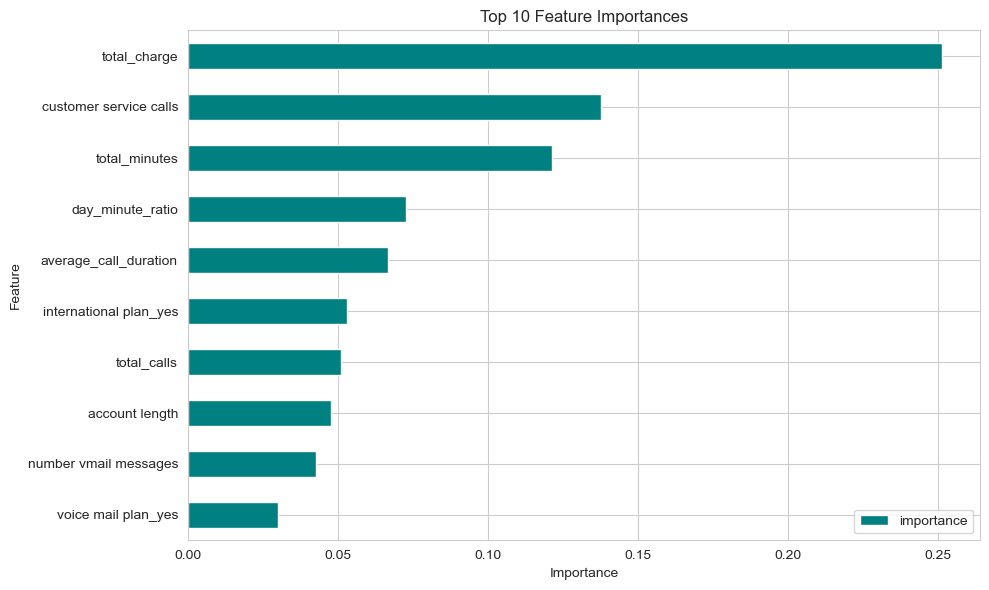

In [36]:
# Get feature importances (for tree-based models)
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Display top features
    print("Top 10 Most Important Features:")
    print(feature_importance.head(10))
    
    # Plot feature importances
    plt.figure(figsize=(10, 6))
    feature_importance.head(10).plot(x='feature', y='importance', kind='barh', color='teal')
    plt.title('Top 10 Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model type.")

### 5.3 ROC Curve and AUC Score

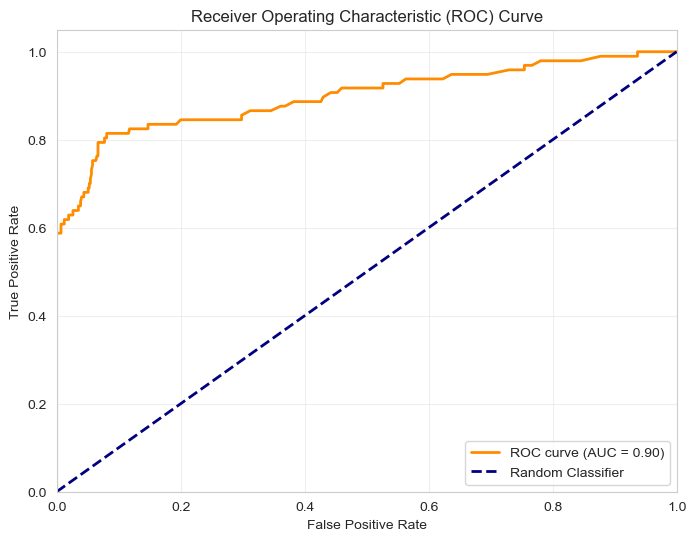


AUC Score: 0.8979


In [37]:
# Get probability predictions
y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")

### 5.4 Model Limitations and Considerations

**Limitations:**
- [Discuss where the model performs poorly]
- [Note any class imbalance issues]
- [Identify types of customers the model might misclassify]
- [Discuss potential real-world deployment challenges]

**Considerations for Production:**
- [Model maintenance and retraining needs]
- [Data quality requirements]
- [Ethical considerations]
- [Potential for model drift]

---

## 6. Conclusions and Recommendations <a id='conclusions-and-recommendations'></a>

### 6.1 Summary of Findings

**Model Performance:**
- [Summarize final model performance]
- [Highlight key metrics relevant to the business problem]

**Key Predictors of Churn:**
- [List top 3-5 most important features]
- [Explain what these mean in business terms]

**Model Insights:**
- [What patterns did the model identify?]
- [Which customers are most at risk?]
- [What behaviors or characteristics predict churn?]

### 6.2 Business Recommendations

Based on the model findings, here are actionable recommendations for SyriaTel:

1. **[Recommendation 1 based on important feature]**
   - What to do: [specific action]
   - Expected impact: [potential benefit]
   - Implementation: [how to do it]

2. **[Recommendation 2 based on important feature]**
   - What to do: [specific action]
   - Expected impact: [potential benefit]
   - Implementation: [how to do it]

3. **[Recommendation 3 based on model performance]**
   - What to do: [specific action]
   - Expected impact: [potential benefit]
   - Implementation: [how to do it]

### 6.3 Next Steps

**For Model Improvement:**
- [Suggest additional features to collect]
- [Propose advanced techniques to try]
- [Mention ensemble methods or other algorithms]

**For Business Implementation:**
- [Pilot program suggestions]
- [A/B testing recommendations]
- [Monitoring and evaluation plan]

**For Further Analysis:**
- [Additional questions to explore]
- [Deeper dives into specific customer segments]
- [Cost-benefit analysis of interventions]

---

## Final Notes

This analysis has demonstrated the application of machine learning classification techniques to predict customer churn for SyriaTel. The iterative modeling approach allowed us to build progressively better models, and the final model provides actionable insights that can help reduce customer churn and improve business outcomes.

**Key Takeaways:**
- [Main finding 1]
- [Main finding 2]
- [Main finding 3]

---

*End of Analysis*